### OUTLIER ANALYSIS (MOST IMP)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
data={
    "Name":['A','B','C','D','E','F','G','H','I','J'],
    "Marks":[85,72,90,80,88,91,95,87,300,5],
    "Age":[21,19,23,20,22,21,24,23,20,18],
    "City":['ahmedabad','delhi','delhi','mumbai','ahmedabad','rajkot','surat','mumbai','surat','surat']
}
df=pd.DataFrame(data)
df

,Name,Marks,Age,City
0,A,85,21,ahmedabad
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
4,E,88,22,ahmedabad
5,F,91,21,rajkot
6,G,95,24,surat
7,H,87,23,mumbai
8,I,300,20,surat
9,J,5,18,surat


## FILTERING

In [8]:
df

,Name,Marks,Age,City
0,A,85,21,ahmedabad
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
4,E,88,22,ahmedabad
5,F,91,21,rajkot
6,G,95,24,surat
7,H,87,23,mumbai
8,I,300,20,surat
9,J,5,18,surat


## Students with marks > 80

In [9]:
df['Marks']>80

0     True
1    False
2     True
3    False
4     True
5     True
6     True
7     True
8     True
9    False
Name: Marks, dtype: bool

In [10]:
df[df['Marks']>80]

,Name,Marks,Age,City
0,A,85,21,ahmedabad
2,C,90,23,delhi
4,E,88,22,ahmedabad
5,F,91,21,rajkot
6,G,95,24,surat
7,H,87,23,mumbai
8,I,300,20,surat


## == operator

In [12]:
df[df['City']=='delhi']

,Name,Marks,Age,City
1,B,72,19,delhi
2,C,90,23,delhi


### `&` operator
- **Students with age>21 and marks>85**

In [16]:
df['Age'] > 21 & df['Marks'] > 85 # whenever there is chained condition we enclosed them in ()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [13]:
(df['Age'] > 21) & (df['Marks'] > 85)

0    False
1    False
2     True
3    False
4     True
5    False
6     True
7     True
8    False
9    False
dtype: bool

In [17]:
df[(df['Age'] > 21) & (df['Marks'] > 85)]

,Name,Marks,Age,City
2,C,90,23,delhi
4,E,88,22,ahmedabad
6,G,95,24,surat
7,H,87,23,mumbai


### `|` operator (OR operator)
- **Students from delhi or mumbai**

In [19]:
(df['City']=='mumbai') | (df['City']=='delhi')

0    False
1     True
2     True
3     True
4    False
5    False
6    False
7     True
8    False
9    False
Name: City, dtype: bool

In [20]:
df[(df['City']=='mumbai') | (df['City']=='delhi')]

,Name,Marks,Age,City
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
7,H,87,23,mumbai


### BOX PLOT TO VISUALIZE THE OUTLIER

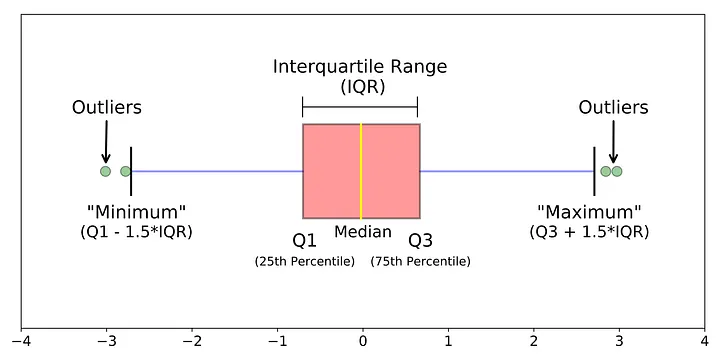

- Boxplot is an effective statistical tool to visualize the outliers and other matrix

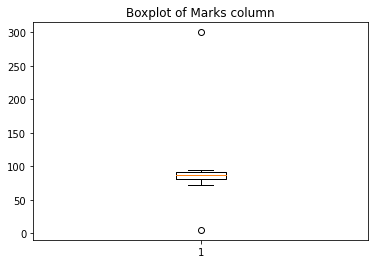

In [21]:
plt.boxplot(df['Marks'])
plt.title('Boxplot of Marks column')
plt.show()

### FUNCTION TO DETECT OUTLIERS

In [28]:
def detectoutlier(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    
    outlier=df[(df[column] < lower) | (df[column] > upper)]
    
    return outlier

In [29]:
detectoutlier(df,'Marks')

,Name,Marks,Age,City
8,I,300,20,surat
9,J,5,18,surat


### FUNCTION TO REMOVE OUTLIERS

In [36]:
def removeoutlier(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    
    cleandf=df[(df[column] >= lower) & (df[column] <= upper)]
    
    return cleandf

In [39]:
removeoutlier(df,'Marks')

,Name,Marks,Age,City
0,A,85,21,ahmedabad
1,B,72,19,delhi
2,C,90,23,delhi
3,D,80,20,mumbai
4,E,88,22,ahmedabad
5,F,91,21,rajkot
6,G,95,24,surat
7,H,87,23,mumbai


In [38]:
df1=removeoutlier(df,'Marks')

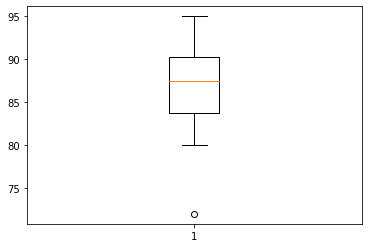

In [42]:
plt.boxplot(df1['Marks'])
plt.show()